# Representación $\sigma_{CKM}$ frente a coeficiente de correlación en factores teóricos y experimentales

rho_input  |       Delta_CKM        | Tensión (sigmas)
--------------------------------------------------------
     -1.00 | 0.00121 +/- 0.00057 |           2.11 σ
     -0.49 | 0.00126 +/- 0.00057 |           2.19 σ
      0.01 | 0.00133 +/- 0.00058 |           2.32 σ
      0.52 | 0.00152 +/- 0.00057 |           2.65 σ
      1.00 | 0.01312 +/- 0.00005 |         271.39 σ


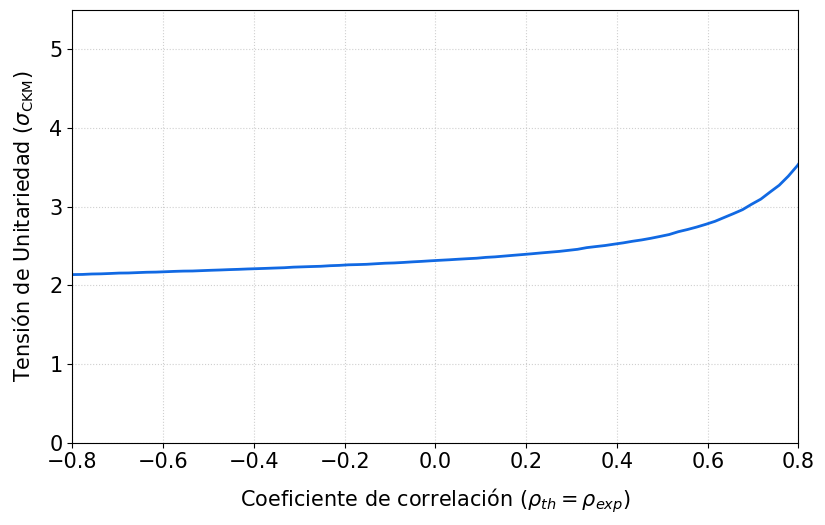

In [3]:
import numpy as np
import gvar as gv
import matplotlib.pyplot as plt
import matplotlib as mpl


# Lectura de datos desde el fichero de texto generado por el script de ajuste
nombre_fichero = "analisis_sensibilidad_rho.txt"

# np.loadtxt ignora automáticamente todas las líneas de encabezado que empiezan con '#'
# Busca esta línea en tu script de lectura:
datos = np.loadtxt(nombre_fichero, encoding='utf-8')  

rho_input  = datos[:, 0]  # Coeficiente de correlación inyectado
vud_mean   = datos[:, 1]  # Medias de Vud
vud_sdev   = datos[:, 2]  # Errores de Vud
vus_mean   = datos[:, 3]  # Medias de Vus
vus_sdev   = datos[:, 4]  # Errores de Vus
rho_ajuste = datos[:, 5]  # Coeficiente de correlación final devuelto por lsqfit

# Listas vacías para almacenar los cálculos vectoriales
delta_medias = []
delta_errores = []
sigmas_ckm = []


# PROPAGACIÓN DE ERRORES CORRELACIONADOS CON GVAR
for i in range(len(rho_input)):
    # covarianza cruzada empleando la rho del ajuste (lsqfit)
    cov_vud_vus = rho_ajuste[i] * vud_sdev[i] * vus_sdev[i]
    
    # Construimos la matriz de covarianza 2x2 para esta iteración
    matriz_cov = np.array([
        [vud_sdev[i]**2, cov_vud_vus],
        [cov_vud_vus,    vus_sdev[i]**2]
    ])
    
    # ambas variables acopladas mediante gvar
    vud_gv, vus_gv = gv.gvar([vud_mean[i], vus_mean[i]], matriz_cov)
    
    # Calculamos el test de unitariedad Delta_CKM con propagación de errores
    delta_gv = 1 - vud_gv**2 - vus_gv**2
    
    # Almacenamos el valor central y su incertidumbre total corregida
    delta_medias.append(delta_gv.mean)
    delta_errores.append(delta_gv.sdev)
    
    # Calculamos la desviación en unidades de sigma (distancia estadística al cero)
    # sigma = Delta_CKM / error_Delta
    sigmas_ckm.append(delta_gv.mean / delta_gv.sdev)

# Convertimos las listas a arrays de numpy para la representación gráfica
delta_medias = np.array(delta_medias)
delta_errores = np.array(delta_errores)
sigmas_ckm = np.array(sigmas_ckm)

# Mostramos en pantalla una pequeña muestra del resultado para verificar
print(f"{'rho_input':^10} | {'Delta_CKM':^22} | {'Tensión (sigmas)':^16}")
print("-" * 56)
for idx in [0, 25, 50, 75, -1]: # Muestra representativa 
    print(f"{rho_input[idx]:10.2f} | {delta_medias[idx]:.5f} +/- {delta_errores[idx]:.5f} | {sigmas_ckm[idx]:14.2f} σ")


# REPRESENTACIÓN GRÁFICA 
mpl.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15
})

fig, ax = plt.subplots(figsize=(8.5, 5.5))

# Dibujamos la curva del valor central
ax.plot(rho_input, sigmas_ckm, color="#1169e3", lw=2, label=r'Tensión estadística ($\sigma_{\mathrm{CKM}}$)')

# Ajustes de formato, rejilla y leyendas
#ax.set_title('Evolución de la Anomalía CKM según la  Correlación', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel(r'Coeficiente de correlación ($\rho_{th}=\rho_{exp}$)', labelpad=10)
ax.set_ylabel(r'Tensión de Unitariedad $(\sigma_{\mathrm{CKM}})$', labelpad=10)

ax.grid(True, linestyle=':', alpha=0.6)
#ax.legend(loc='upper right', frameon=True, edgecolor='lightgray', fontsize=10.5)

# FLimites
ax.set_xlim(-0.8, 0.8)
ax.set_xticks(np.linspace(-0.8, 0.8, 9))
ax.set_ylim(0, 5.5)

# Guardado en formato PDF
plt.tight_layout()
plt.savefig('grafica_sensibilidad_SIGMA_ckm.pdf', format='pdf', bbox_inches='tight')
plt.show()

rho_input  |       Delta_CKM       
--------------------------------------------------------
     -1.00 | 0.00121 +/- 0.00057
     -0.49 | 0.00126 +/- 0.00057
      0.01 | 0.00133 +/- 0.00058
      0.52 | 0.00152 +/- 0.00057
      1.00 | 0.01312 +/- 0.00005


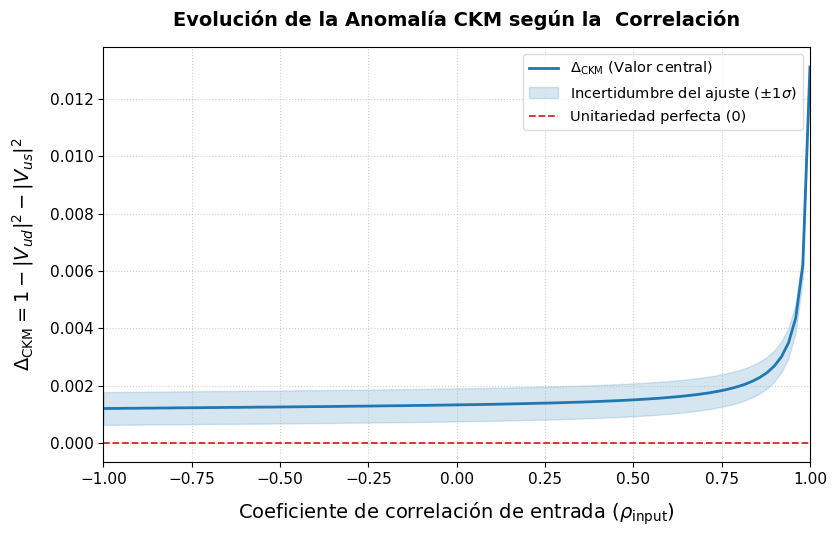

In [24]:
import numpy as np
import gvar as gv
import matplotlib.pyplot as plt
import matplotlib as mpl


# LECTURA DEL FICHERO DE RESULTADOS
nombre_fichero = "analisis_sensibilidad_rho.txt"

# np.loadtxt ignora automáticamente todas las líneas de encabezado que empiezan con '#'
datos = np.loadtxt(nombre_fichero, encoding='utf-8')

rho_input  = datos[:, 0]  # Coeficiente de correlación inyectado
vud_mean   = datos[:, 1]  # Medias de Vud
vud_sdev   = datos[:, 2]  # Errores de Vud
vus_mean   = datos[:, 3]  # Medias de Vus
vus_sdev   = datos[:, 4]  # Errores de Vus
rho_ajuste = datos[:, 5]  # Coeficiente de correlación final devuelto por lsqfit

# Listas vacías para almacenar los cálculos vectoriales
delta_medias = []
delta_errores = []
sigmas_ckm = []

# PROPAGACIÓN DE ERRORES CORRELACIONADOS CON GVAR
for i in range(len(rho_input)):
    # Reconstruimos la covarianza cruzada empleando la rho del ajuste (lsqfit)
    cov_vud_vus = rho_ajuste[i] * vud_sdev[i] * vus_sdev[i]
    
    # Construimos la matriz de covarianza 2x2 para esta iteración
    matriz_cov = np.array([
        [vud_sdev[i]**2, cov_vud_vus],
        [cov_vud_vus,    vus_sdev[i]**2]
    ])
    
    # ambas variables acopladas mediante gvar
    vud_gv, vus_gv = gv.gvar([vud_mean[i], vus_mean[i]], matriz_cov)
    
    # Calculamos el test de unitariedad Delta_CKM con propagación de errores
    delta_gv = 1 - vud_gv**2 - vus_gv**2
    
    # Almacenamos el valor central y su incertidumbre total corregida
    delta_medias.append(delta_gv.mean)
    delta_errores.append(delta_gv.sdev)

# Convertimos las listas a arrays de numpy para la representación gráfica
delta_medias = np.array(delta_medias)
delta_errores = np.array(delta_errores)
sigmas_ckm = np.array(sigmas_ckm)

# Mostramos en pantalla una pequeña muestra del resultado para verificar
print(f"{'rho_input':^10} | {'Delta_CKM':^22}")
print("-" * 56)
for idx in [0, 25, 50, 75, -1]: # Muestra representativa
    print(f"{rho_input[idx]:10.2f} | {delta_medias[idx]:.5f} +/- {delta_errores[idx]:.5f}")


# REPRESENTACIÓN GRÁFICA FORMAL 
mpl.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

fig, ax = plt.subplots(figsize=(8.5, 5.5))

# Dibujamos la curva del valor central
ax.plot(rho_input, delta_medias, color='#1f77b4', lw=2, label=r'$\Delta_{\mathrm{CKM}}$ (Valor central)')

# banda de incertidumbre +/- 1 sigma usando fill_between
ax.fill_between(rho_input, 
                delta_medias - delta_errores, 
                delta_medias + delta_errores, 
                color='#1f77b4', 
                alpha=0.18, 
                label=r'Incertidumbre del ajuste ($\pm 1\sigma$)')

# Línea horizontal de referencia en 0 (Unitariedad estricta del SM)
ax.axhline(0, color='#d62728', linestyle='--', lw=1.3, label='Unitariedad perfecta (0)')

# Ajustes de formato, rejilla y leyendas
ax.set_title('Evolución de la Anomalía CKM según la  Correlación', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel(r'Coeficiente de correlación de entrada ($\rho_{\mathrm{input}}$)', labelpad=10)
ax.set_ylabel(r'$\Delta_{\mathrm{CKM}} = 1 - |V_{ud}|^2 - |V_{us}|^2$', labelpad=10)

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', frameon=True, edgecolor='lightgray', fontsize=10.5)


ax.set_xlim(-1, 1)

# Guardado en formato PDF
plt.tight_layout()
plt.savefig('grafica_sensibilidad_delta_ckm.pdf', format='pdf', bbox_inches='tight')
plt.show()

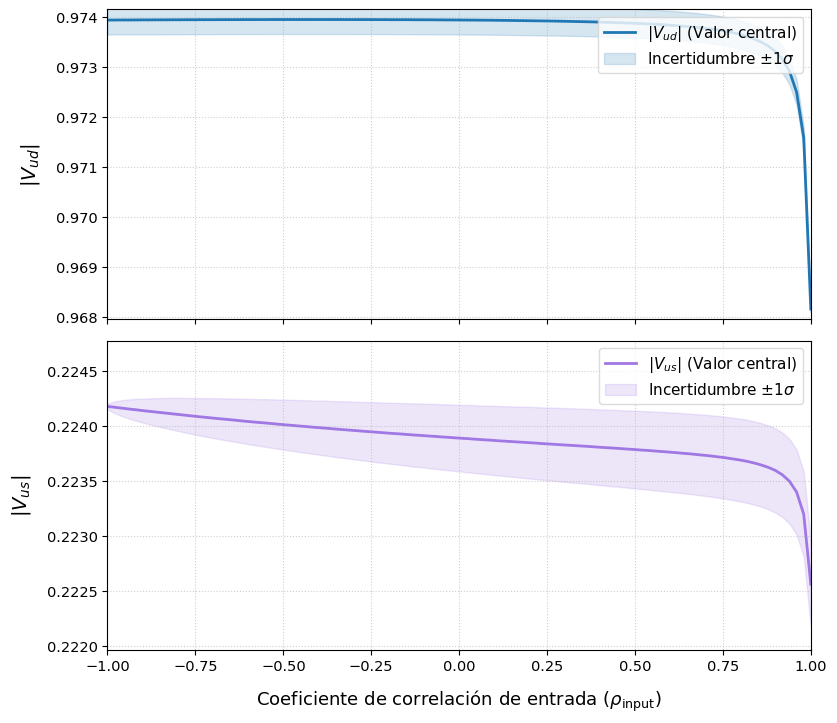

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


# LECTURA DEL FICHERO DE RESULTADOS 
nombre_fichero = "analisis_sensibilidad_rho.txt"
datos = np.loadtxt(nombre_fichero, encoding='utf-8')

rho_input  = datos[:, 0]  # Coeficiente de correlación inyectado
vud_mean   = datos[:, 1]  # Medias de Vud
vud_sdev   = datos[:, 2]  # Errores de Vud
vus_mean   = datos[:, 3]  # Medias de Vus
vus_sdev   = datos[:, 4]  # Errores de Vus


# REPRESENTACIÓN GRÁFICA EN DOS PANELES 
mpl.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'xtick.labelsize': 10.5,
    'ytick.labelsize': 10.5
})

# figura con 2 subplots verticales (sharex=True comparte el eje X)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 8.0), sharex=True)


# PANEL SUPERIOR: Evolución de |Vud|
ax1.plot(rho_input, vud_mean, color='#1f77b4', lw=2, label=r'$|V_{ud}|$ (Valor central)')
ax1.fill_between(rho_input, vud_mean - vud_sdev, vud_mean + vud_sdev, 
                 color='#1f77b4', alpha=0.18, label=r'Incertidumbre $\pm 1\sigma$')

ax1.set_ylabel(r'$|V_{ud}|$', fontsize=14, labelpad=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', frameon=True, edgecolor='lightgray')

# Recorte del eje Y para |Vud| (Ajusta estos límites según tus datos reales si es necesario)
# Evita que las esquinas colapsadas deformen la escala visual central
ax1.set_ylim(np.min(vud_mean) - 0.0002, np.max(vud_mean) + 0.0002) 


# PANEL INFERIOR: Evolución de |Vus|
ax2.plot(rho_input, vus_mean, color="#a077e3", lw=2, label=r'$|V_{us}|$ (Valor central)')
ax2.fill_between(rho_input, vus_mean - vus_sdev, vus_mean + vus_sdev, 
                 color='#a077e3', alpha=0.18, label=r'Incertidumbre $\pm 1\sigma$')

ax2.set_xlabel(r'Coeficiente de correlación de entrada ($\rho_{\mathrm{input}}$)', labelpad=10)
ax2.set_ylabel(r'$|V_{us}|$', fontsize=14, labelpad=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=True, edgecolor='lightgray')

# Recorte del eje Y para |Vus| (Ajusta estos límites según tus datos reales si es necesario)
ax2.set_ylim(np.min(vus_mean) - 0.0006, np.max(vus_mean) + 0.0006)


# Forzamos límites y marcas limpias en el eje X común de -1 a 1
ax2.set_xlim(-1, 1)
ax2.set_xticks(np.linspace(-1, 1, 9))

# Ajuste automático de márgenes para evitar solapamientos entre paneles
plt.tight_layout()
# Desplazamos un pelín los gráficos hacia abajo para dar espacio al título global (suptitle)
plt.subplots_adjust(top=0.90) 

# Guardado definitivo en formato PDF
plt.savefig('grafica_sensibilidad_Vud_Vus.pdf', format='pdf', bbox_inches='tight')
plt.show()

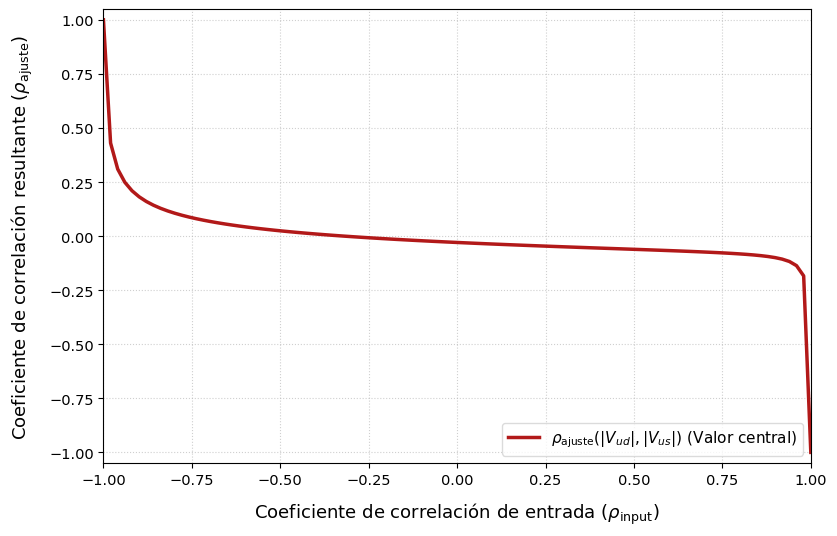

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


# LECTURA DEL FICHERO DE RESULTADOS
nombre_fichero = "analisis_sensibilidad_rho.txt"
datos = np.loadtxt(nombre_fichero, encoding='utf-8')

rho_input  = datos[:, 0]  # Coeficiente de correlación inyectado (Entrada)
rho_ajuste = datos[:, 5]  # Coeficiente de correlación final devuelto por lsqfit (Salida)


mpl.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'xtick.labelsize': 10.5,
    'ytick.labelsize': 10.5
})

# Creamos una figura con 1 solo subplot (panel único) con proporciones apaisadas
fig, ax = plt.subplots(figsize=(8.5, 5.5))


# Evolución de rho_ajuste
ax.plot(rho_input, rho_ajuste, color="#b21919", lw=2.5, 
        label=r'$\rho_{\mathrm{ajuste}}(|V_{ud}|, |V_{us}|)$ (Valor central)')

ax.set_xlabel(r'Coeficiente de correlación de entrada ($\rho_{\mathrm{input}}$)', labelpad=10)
ax.set_ylabel(r'Coeficiente de correlación resultante ($\rho_{\mathrm{ajuste}}$)', labelpad=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', frameon=True, edgecolor='lightgray')

# Forzamos límites y marcas limpias en el eje X de -1 a 1
ax.set_xlim(-1, 1)
ax.set_xticks(np.linspace(-1, 1, 9))

# Forzamos los mismos límites y marcas en el eje Y (ya que es un coeficiente de correlación)
ax.set_ylim(-1.05, 1.05)
ax.set_yticks(np.linspace(-1, 1, 9))

# Ajuste automático de márgenes
plt.tight_layout()

# Guardado definitivo en formato vectorial de alta fidelidad
plt.savefig('grafica_sensibilidad_rho_ajuste.pdf', format='pdf', bbox_inches='tight')
plt.show()